[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# When the Transformer Earns Its Keep: Natural Language Inference

This module has delivered an uncomfortable result.  On IMDb sentiment, a linear model on word counts — TF-IDF + logistic regression — reaches ~0.91, and our recurrent network, our from-scratch transformer, and even a frozen BERT struggle to clearly beat it.  The reason is that movie-review sentiment is a *lexical* task: the answer is mostly in *which words appear* ("waste", "brilliant"), so counting the right words is nearly enough.  For a task like that, the transformer's machinery is expensive overkill.

So when does that machinery pay off?  When the answer depends on **structure and relationships**, not just word identity.  This notebook shows one such task and climbs a four-rung ladder on it, separating what the *architecture* buys from what *pretraining* buys:

1. **TF-IDF + logistic regression** — the bag-of-words baseline that dominated IMDb.
2. **A transformer we train from scratch** (with GloVe word vectors) — our own encoder, trained by us. Isolates what the *architecture* adds, once the words carry meaning.
3. **A pretrained BERT we fine-tune** — the same task training, but starting from a model that already knows language. Isolates what *pretraining* adds.
4. **An off-the-shelf NLI model** — pretrained *and* already fine-tuned on this task by someone else. The ceiling, for free.

On IMDb these four would land in a dead heat; here they spread out, and the spread is the lesson.

## The task

**Natural language inference** (NLI): given a *premise* and a *hypothesis*, decide whether the hypothesis is **entailment** (must be true if the premise is), **contradiction** (cannot be true), or **neutral** (could be either).

| premise | hypothesis | label |
|---|---|---|
| A soccer game with multiple males playing. | Some men are playing a sport. | entailment |
| A man inspects his uniform. | The man is sleeping. | contradiction |
| An older woman sits with a drink. | A woman is waiting for her order. | neutral |

The answer lives in *how the sentences relate*, not which words appear — exactly what bag-of-words throws away and what all-pairs attention is built to capture.  We use the **Stanford Natural Language Inference (SNLI)** corpus.

*This notebook downloads SNLI, GloVe word vectors, and pretrained models, and trains two networks, so it needs internet on first run, `transformers` installed, and ideally a GPU/Apple-MPS (the two training cells are slow on a CPU; reduce the sizes set below).*

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import math
import os
import re
import zipfile
import urllib.request
from collections import Counter

import numpy as np
import torch
from torch import nn

device = ('cuda' if torch.cuda.is_available()
          else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using {device} device')

# subset sizes -- shared across models for a fair comparison.
# REDUCE on a CPU (e.g. 3000 / 1000); raise on a GPU for higher accuracy.
TRAIN_N, TEST_N = 10000, 2000


def _download(urls, archive):
    """Fetch the first working URL (browser User-Agent avoids many 403s)."""
    err = None
    for url in urls:
        try:
            print('downloading', url, '...')
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(req) as r:
                payload = r.read()
            with open(archive, 'wb') as out:
                out.write(payload)
            return
        except Exception as e:
            print('  failed:', e)
            err = e
    raise RuntimeError(f'could not download ({err}); fetch it manually')


def download_snli(data_dir='../data'):
    os.makedirs(data_dir, exist_ok=True)
    archive = os.path.join(data_dir, 'snli_1.0.zip')
    extracted = os.path.join(data_dir, 'snli_1.0')
    if not os.path.exists(extracted):
        if not os.path.exists(archive):
            _download(['https://nlp.stanford.edu/projects/snli/snli_1.0.zip',
                       'https://d2l-data.s3-accelerate.amazonaws.com/snli_1.0.zip'],
                      archive)
        with zipfile.ZipFile(archive) as z:
            z.extractall(data_dir)
    return extracted

LABELS = {'entailment': 0, 'contradiction': 1, 'neutral': 2}

def read_snli(data_dir, split):
    """(premises, hypotheses, labels): gold label is column 0, sentences are
    columns 5 and 6; rows with no gold label ('-') are dropped."""
    fname = os.path.join(data_dir, f'snli_1.0_{split}.txt')
    prem, hyp, lab = [], [], []
    with open(fname, encoding='utf-8') as f:
        for row in f.readlines()[1:]:
            c = row.split('\t')
            if c[0] in LABELS:
                prem.append(c[5]); hyp.append(c[6]); lab.append(LABELS[c[0]])
    return prem, hyp, lab

def subsample(p, h, y, n, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(y))[:n]
    return ([p[i] for i in idx], [h[i] for i in idx],
            np.array([y[i] for i in idx]))

data_dir = download_snli()
p_train, h_train, y_train = subsample(*read_snli(data_dir, 'train'), n=TRAIN_N)
p_test, h_test, y_test = subsample(*read_snli(data_dir, 'test'), n=TEST_N)
yt, ye = torch.tensor(y_train), torch.tensor(y_test)   # label tensors
print(len(p_train), 'train /', len(p_test), 'test pairs')
print('label balance (train):', np.bincount(y_train))

Using mps device
10000 train / 2000 test pairs
label balance (train): [3274 3396 3330]


## Reading the pair jointly: the cross-encoder

Before the models, a word about *how* a transformer is fed a pair of sentences — because that structure does more work than it looks.

All three transformer rungs below read the premise and hypothesis as a **single sequence**, glued together with special tokens:

```
[CLS]  premise tokens ...  [SEP]  hypothesis tokens ...
```

A model that ingests two texts this way — jointly, so they interact *inside* the network — is a **cross-encoder**.  Its opposite is a **bi-encoder**, which runs each text through the encoder *separately*, produces one vector per text, and then compares the two vectors (a dot product, say).  Bi-encoders are fast and their vectors can be precomputed and cached, which is why they power large-scale semantic search — but because the two texts never meet until that final comparison, they cannot do the word-by-word reasoning NLI needs.  The cross-encoder pays for every pair with a full forward pass and, in return, lets every token of one sentence attend to every token of the other, at every layer.  The figure below shows why that matters for a contradiction example:

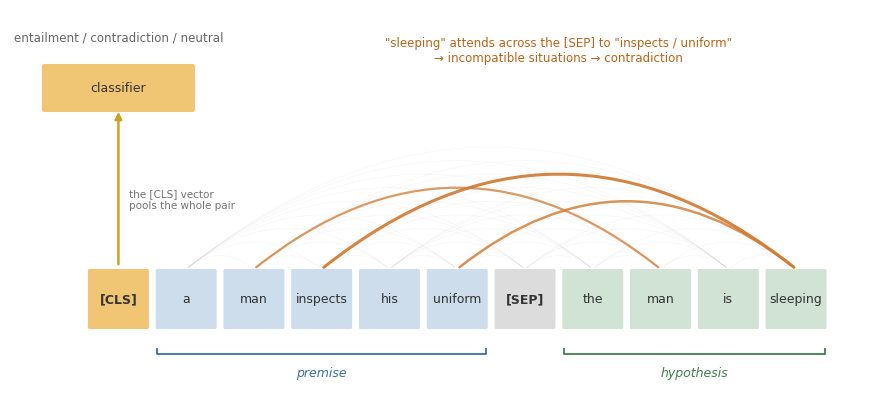

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

tokens = ['[CLS]', 'a', 'man', 'inspects', 'his', 'uniform', '[SEP]',
          'the', 'man', 'is', 'sleeping']          # 1-5 premise, 7-10 hypothesis
PREM, HYP, CLS, SEP, TX = '#cdddec', '#d0e3d4', '#f0c674', '#dcdcdc', '#333333'
def color(i):
    return CLS if i == 0 else SEP if i == 6 else (PREM if i < 6 else HYP)

fig, ax = plt.subplots(figsize=(9, 4.2))
BW = 0.86
for i, tok in enumerate(tokens):
    ax.add_patch(FancyBboxPatch((i - BW/2, -0.28), BW, 0.56,
                 boxstyle='round,pad=0.02', facecolor=color(i), edgecolor='none'))
    ax.text(i, 0, tok, ha='center', va='center', fontsize=9, color=TX,
            fontweight='bold' if tok in ('[CLS]', '[SEP]') else 'normal')

def bracket(x0, x1, label, col):
    ax.plot([x0, x0, x1, x1], [-0.50, -0.55, -0.55, -0.50], color=col, lw=1.3)
    ax.text((x0 + x1) / 2, -0.67, label, ha='center', va='top', fontsize=9,
            color=col, style='italic')
bracket(1 - BW/2, 5 + BW/2, 'premise', '#3b6ea5')
bracket(7 - BW/2, 10 + BW/2, 'hypothesis', '#3f7d4f')

def arc(i, j, col, lw, alpha):
    ax.annotate('', xy=(j, 0.30), xytext=(i, 0.30),
                arrowprops=dict(arrowstyle='-', color=col, lw=lw, alpha=alpha,
                                connectionstyle='arc3,rad=-0.4'))
for i in range(1, 11):                     # faint: every token attends to every other
    for j in range(i + 1, 11):
        if (i, j) not in [(3, 10), (5, 10), (2, 8)]:
            arc(i, j, '0.6', 0.4, 0.10)
arc(3, 10, '#d0782f', 2.2, 0.9)            # inspects <-> sleeping
arc(5, 10, '#d0782f', 1.8, 0.8)            # uniform  <-> sleeping
arc(2, 8, '#d0782f', 1.6, 0.75)            # man <-> man
ax.text(6.5, 2.35,
        '"sleeping" attends across the [SEP] to "inspects / uniform"\n'
        '→ incompatible situations → contradiction',
        ha='center', va='bottom', fontsize=8.5, color='#b5651d')

ax.annotate('', xy=(0, 1.9), xytext=(0, 0.32),
            arrowprops=dict(arrowstyle='-|>', color='#c9a227', lw=1.8))
ax.add_patch(FancyBboxPatch((-1.1, 1.9), 2.2, 0.42, boxstyle='round,pad=0.03',
             facecolor=CLS, edgecolor='none'))
ax.text(0, 2.11, 'classifier', ha='center', va='center', fontsize=9, color=TX)
ax.text(0, 2.62, 'entailment / contradiction / neutral', ha='center',
        va='center', fontsize=8.5, color='0.4')
ax.text(0.15, 1.0, 'the [CLS] vector\npools the whole pair', ha='left',
        va='center', fontsize=7.5, color='0.45')
ax.set_xlim(-1.6, 11); ax.set_ylim(-1.0, 2.9); ax.axis('off')
plt.tight_layout();

The `[SEP]` token marks the boundary, but self-attention pays it no special respect: a hypothesis word like *sleeping* attends straight across it to *inspects* and *uniform* in the premise, finds that the two describe incompatible situations, and writes that evidence into its representation — which the `[CLS]` slot then pools for the classifier.  Bag-of-words had all of these same words; what it lacked was any way to *connect* them across the two sentences.  That connection is the cross-encoder's whole advantage.

**Aside — wouldn't an RNN be natural here?**  It is a fair intuition: an RNN reads left to right, so by the time it reaches the hypothesis it has already seen the premise, and its sense of *before* and *after* the separator is built in.  The first strong SNLI models were exactly this — an LSTM reads the premise, then reads the hypothesis conditioned on it.  But they hit a bottleneck: the premise is crushed into one fixed hidden state before the hypothesis is even seen.  The historical fix was to add *attention* so hypothesis words could look back at specific premise words (Rocktäschel et al., 2015) — at which point you have reinvented most of a transformer.  The cross-encoder simply makes attention the entire architecture: no bottleneck, every cross-sentence comparison available from the first layer.

**Does the transformer know which side of `[SEP]` a token is on?**  Partly it is *told*, partly it *learns* it — and the story ties back to positional encoding.  Position already marks premise tokens as early and hypothesis tokens as late, so the encoding we added in notebook 4 *to cure order-blindness* now does double duty as segment information.  Original BERT went further, adding a learned **segment embedding** — a "sentence A" vs "sentence B" vector — to every token.  Tellingly, RoBERTa and DistilBERT (including our rung-4 model) **dropped segment embeddings entirely** and work just as well, direct evidence that a multi-layer transformer *learns* segment membership from the `[SEP]` landmark and position on its own.  Probing studies bear this out: some attention heads use `[SEP]` as a landmark, some stay within a segment while others cross it, and higher layers come to encode the cross-sentence relation itself.

## Rung 1 — the bag-of-words baseline

We repeat exactly the approach that dominated IMDb: TF-IDF features and a logistic regression, concatenating the two sentences so it can count words and bigrams across the pair.

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

def join(prem, hyp):
    return [p + ' [SEP] ' + h for p, h in zip(prem, hyp)]

vec = TfidfVectorizer(ngram_range=(1, 2), min_df=5, sublinear_tf=True)
Xtr = vec.fit_transform(join(p_train, h_train))
Xte = vec.transform(join(p_test, h_test))

clf = LogisticRegression(C=10, max_iter=1000)
clf.fit(Xtr, y_train)
acc_tfidf = clf.score(Xte, y_test)
print(f'TF-IDF + logistic regression accuracy: {acc_tfidf:.3f}   '
      f'(3-way chance = 0.33)')

TF-IDF + logistic regression accuracy: 0.483   (3-way chance = 0.33)


On a 10k subset this lands around **0.48** — far below its ~0.91 on IMDb, only modestly above the chance/bias floor, and nowhere near usable.  The words are all present, but scrambled across two sentences with the *relationship* discarded, they do not carry the answer.  A strong baseline has met a task it cannot do.  Now let us train some deep models.

## Rung 2 — a transformer we train from scratch (with GloVe vectors)

We build the encoder from notebook 6 — multi-head self-attention with a `<cls>` readout — and train it on SNLI ourselves.  But we give it one running start a bag-of-words never gets: **pretrained word embeddings**.  We tokenize into words, build a vocabulary from the training pairs, and initialize the embedding layer with 100-dimensional **GloVe** vectors (the same word vectors the CNN used in the recurrent module); the attention layers and classifier are random and trained from scratch.

Why the leg-up?  A transformer trained *purely* from scratch on a few thousand pairs is data-starved: with a large random embedding table it never learns what the words mean, and lands at or below the bag-of-words baseline (~0.45 — try it by skipping the GloVe step).  GloVe hands the model word meanings up front, so the limited data can go toward learning the *relational* task.  The model reads the pair as `[<cls>] premise [<sep>] hypothesis` and classifies the `<cls>` output.

In [3]:
# --- word-level tokenizer + vocabulary from the training pairs ---
def tokenize(text):
    return re.findall(r"[a-z0-9']+", text.lower())

counter = Counter()
for p, h in zip(p_train, h_train):
    counter.update(tokenize(p)); counter.update(tokenize(h))
specials = ['<pad>', '<cls>', '<sep>', '<unk>']
itos = specials + [w for w, c in counter.most_common() if c >= 2]
stoi = {w: i for i, w in enumerate(itos)}
PAD, CLS, SEP, UNK = 0, 1, 2, 3
print(f'vocabulary size: {len(itos):,}')

def encode_pair(prem, hyp, max_len=64):
    ids = ([CLS] + [stoi.get(w, UNK) for w in tokenize(prem)] + [SEP]
           + [stoi.get(w, UNK) for w in tokenize(hyp)])[:max_len]
    return ids + [PAD] * (max_len - len(ids))

def encode_all(prem, hyp):
    ids = torch.tensor([encode_pair(p, h) for p, h in zip(prem, hyp)])
    return ids, (ids != PAD).long()

ids_train, mask_train = encode_all(p_train, h_train)
ids_test, mask_test = encode_all(p_test, h_test)


# --- GloVe word vectors, aligned to our vocabulary ---
def download_glove(data_dir='../data'):
    os.makedirs(data_dir, exist_ok=True)
    for cand in ('glove.6B.100d.txt', 'glove.6B.100d/vec.txt'):
        if os.path.exists(os.path.join(data_dir, cand)):
            return os.path.join(data_dir, cand)
    archive = os.path.join(data_dir, 'glove.6B.100d.zip')
    if not os.path.exists(archive):
        _download(['https://d2l-data.s3-accelerate.amazonaws.com/glove.6B.100d.zip',
                   'https://nlp.stanford.edu/data/glove.6B.zip'], archive)
    with zipfile.ZipFile(archive) as z:
        z.extractall(data_dir)
    for cand in ('glove.6B.100d.txt', 'glove.6B.100d/vec.txt'):
        if os.path.exists(os.path.join(data_dir, cand)):
            return os.path.join(data_dir, cand)
    raise RuntimeError('glove.6B.100d vectors not found after extraction')

def glove_matrix(vocab_stoi, dim=100):
    """Embedding matrix for our vocab: GloVe where available, else random."""
    path = download_glove()
    emb = torch.empty(len(vocab_stoi), dim)
    nn.init.normal_(emb, std=0.1)
    emb[PAD] = 0
    found = 0
    with open(path, encoding='utf-8') as f:
        for line in f:
            word, *rest = line.rstrip().split(' ')
            i = vocab_stoi.get(word)
            if i is not None and len(rest) == dim:
                emb[i] = torch.tensor([float(x) for x in rest]); found += 1
    print(f'{found:,}/{len(vocab_stoi):,} vocab words initialised from GloVe')
    return emb

emb_matrix = glove_matrix(stoi)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=256):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class NLITransformer(nn.Module):
    """The notebook-6 encoder, GloVe-initialised, for sentence pairs."""
    def __init__(self, emb_matrix, nhead=4, num_layers=2):
        super().__init__()
        d_model = emb_matrix.shape[1]
        self.embed = nn.Embedding.from_pretrained(emb_matrix, freeze=False,
                                                  padding_idx=PAD)
        self.pos = PositionalEncoding(d_model)
        layer = nn.TransformerEncoderLayer(d_model, nhead, 4 * d_model,
                                           batch_first=True)
        self.encoder = nn.TransformerEncoder(
            layer, num_layers, enable_nested_tensor=False)
        self.head = nn.Linear(d_model, 3)

    def forward(self, input_ids, attention_mask):
        x = self.pos(self.embed(input_ids))
        x = self.encoder(x, src_key_padding_mask=(attention_mask == 0))
        return self.head(x[:, 0])


def evaluate(model_fn, ids, mask, y, bs=128):
    correct = 0
    with torch.no_grad():
        for i in range(0, len(y), bs):
            logits = model_fn(ids[i:i+bs].to(device), mask[i:i+bs].to(device))
            correct += (logits.argmax(1).cpu() == y[i:i+bs]).sum().item()
    return correct / len(y)

scratch = NLITransformer(emb_matrix).to(device)
opt = torch.optim.AdamW(scratch.parameters(), lr=3e-4)
loss_fn = nn.CrossEntropyLoss()
bs = 64
for epoch in range(10):          # watch the per-epoch accuracy and stop when it plateaus
    scratch.train()
    order = torch.randperm(len(yt)).tolist()
    for i in range(0, len(order), bs):
        idx = order[i:i+bs]
        loss = loss_fn(scratch(ids_train[idx].to(device),
                               mask_train[idx].to(device)), yt[idx].to(device))
        opt.zero_grad(); loss.backward(); opt.step()
    scratch.eval()
    print(f'epoch {epoch+1:2d}: from-scratch test accuracy '
          f'{evaluate(scratch, ids_test, mask_test, ye):.3f}')

vocabulary size: 4,903
downloading https://d2l-data.s3-accelerate.amazonaws.com/glove.6B.100d.zip ...
4,827/4,903 vocab words initialised from GloVe
epoch  1: from-scratch test accuracy 0.400
epoch  2: from-scratch test accuracy 0.510
epoch  3: from-scratch test accuracy 0.533
epoch  4: from-scratch test accuracy 0.521
epoch  5: from-scratch test accuracy 0.569
epoch  6: from-scratch test accuracy 0.569
epoch  7: from-scratch test accuracy 0.558
epoch  8: from-scratch test accuracy 0.559
epoch  9: from-scratch test accuracy 0.559
epoch 10: from-scratch test accuracy 0.517


With GloVe embeddings the from-scratch transformer reaches roughly the **mid-to-high 0.60s** — now a clear step above the bag-of-words ~0.48, which is the whole point: on a *relational* task, attention across the two sentences extracts structure that word-counting cannot, *once the words carry meaning*.  Strip GloVe out (random embeddings) and it collapses back to ~0.45, at or below the baseline: the architecture needs either pretrained embeddings or far more data to help at all.  That data-hunger is exactly what a fully pretrained model cures — the next rung.

(The `range(10)` above is just a heuristic ceiling; the loop prints test accuracy each epoch so you can stop when it plateaus.  With GloVe and 10k pairs it typically levels off within a handful of epochs.)

## Rung 3 — a pretrained BERT we fine-tune

Same task training, different starting point: instead of GloVe-plus-random we start from a fully **pretrained** DistilBERT — a model that already learned language from billions of words — and fine-tune it on SNLI with a fresh 3-class head, using the realistic recipe from the BERT notebook (AdamW, a learning-rate warmup + decay, gradient clipping).  It brings its own subword tokenizer.

In [4]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)

bert_tok = AutoTokenizer.from_pretrained('distilbert-base-uncased')

def bert_encode(prem, hyp, max_len=128):
    enc = bert_tok(prem, hyp, padding='max_length', truncation=True,
                   max_length=max_len, return_tensors='pt',
                   return_token_type_ids=False)
    return enc['input_ids'], enc['attention_mask']

# fine-tuning is the heavy cell (GPU/MPS recommended).  Pretraining lets it
# learn from fewer examples; raise n_ft toward TRAIN_N on a GPU for more.
n_ft = min(TRAIN_N, 3000)
b_ids_train, b_mask_train = bert_encode(p_train[:n_ft], h_train[:n_ft])
b_ids_test, b_mask_test = bert_encode(p_test, h_test)
ft_y = yt[:n_ft]

bert = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=3).to(device)
opt = torch.optim.AdamW(bert.parameters(), lr=2e-5, weight_decay=0.01)
loss_fn = nn.CrossEntropyLoss()
bs, epochs = 16, 3
total = (n_ft + bs - 1) // bs * epochs
sched = get_linear_schedule_with_warmup(opt, int(0.1 * total), total)

for epoch in range(epochs):
    bert.train()
    order = torch.randperm(n_ft).tolist()
    for i in range(0, n_ft, bs):
        idx = order[i:i+bs]
        out = bert(input_ids=b_ids_train[idx].to(device),
                   attention_mask=b_mask_train[idx].to(device)).logits
        loss = loss_fn(out, ft_y[idx].to(device))
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(bert.parameters(), 1.0)
        opt.step(); sched.step()
    bert.eval()
    acc = evaluate(lambda i, m: bert(input_ids=i, attention_mask=m).logits,
                   b_ids_test, b_mask_test, ye)
    print(f'epoch {epoch+1}: fine-tuned BERT test accuracy {acc:.3f}')

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


epoch 1: fine-tuned BERT test accuracy 0.680
epoch 2: fine-tuned BERT test accuracy 0.729
epoch 3: fine-tuned BERT test accuracy 0.738


Even on *less* data than the from-scratch model (a few thousand pairs), fine-tuned DistilBERT climbs into the **high 0.70s** — and toward the low 0.80s with more data or epochs — a large jump over training the same-shaped architecture from scratch.  That gap is *pretraining*: the encoder arrived already understanding words and how they combine, so the SNLI labels only had to teach the entailment decision, not the language.  It is the same data efficiency we saw with the frozen features on IMDb, but here it also lifts accuracy decisively, because the task genuinely needs the language understanding.

## Rung 4 — an off-the-shelf NLI model

For completeness, the free ceiling.  [`cross-encoder/nli-distilroberta-base`](https://huggingface.co/cross-encoder/nli-distilroberta-base) is the *same kind of model* as rung 3 — a transformer that reads the premise and hypothesis together (`[CLS] premise [SEP] hypothesis`) and outputs the three NLI scores — with two differences that both help.  Its encoder is **DistilRoBERTa**: RoBERTa is BERT's architecture pretrained far more heavily (roughly ten times the text, a better masking scheme, and no next-sentence task), and *Distil* is the same six-layer distillation that gave us DistilBERT — so it starts from a stronger representation than our DistilBERT.  And it was fine-tuned (with the SentenceTransformers library) on the *full* **SNLI and MultiNLI** corpora — on the order of a **million** labeled pairs.  We train nothing here; we just run it.

In [5]:
from transformers import pipeline

NLI_MODEL = 'cross-encoder/nli-distilroberta-base'
nli = pipeline('text-classification', model=NLI_MODEL, top_k=None, device=device)
# device is 'mps' on Apple Silicon; switch to device=-1 (CPU) if MPS errors out
print('model label names:', nli.model.config.id2label)   # sanity-check mapping

def nli_predict(premise, hypothesis):
    scores = nli({'text': premise, 'text_pair': hypothesis})
    name = max(scores, key=lambda d: d['score'])['label'].lower()
    return 0 if 'entail' in name else 1 if 'contradict' in name else 2

n_eval = 500
preds = np.array([nli_predict(p, h)
                  for p, h in zip(p_test[:n_eval], h_test[:n_eval])])
acc_offshelf = (preds == y_test[:n_eval]).mean()
print(f'off-the-shelf NLI model accuracy: {acc_offshelf:.3f}   (on {n_eval})')

Device set to use cpu


model label names: {0: 'contradiction', 1: 'entailment', 2: 'neutral'}
off-the-shelf NLI model accuracy: 0.884   (on 500)


**Why it beats the BERT we fine-tuned.**  It is tempting to read rung 4 as a cleverer technique, but it is essentially rung 3's recipe with two advantages — and the larger one is mundane: **data**.  We fine-tuned on ~3,000 SNLI pairs to keep the cell laptop-friendly; this model was trained on the order of a *million* pairs (all of SNLI plus MultiNLI's several genres) — roughly three hundred times the labeled data, and that is most of the gap.  Our rung 3 is simply data-starved by comparison; given the same million pairs it would close most of the distance.  The smaller advantage is the stronger DistilRoBERTa base.  So rung 4 is not magic: it is *more of what rung 3 already had* — a better pretrained encoder and far more task data — and someone else already paid for both.

## The ladder

Line the four rungs up (your exact numbers will vary with the random subset and training budget):

| model | what it is | NLI accuracy | IMDb accuracy |
|---|---|---|---|
| TF-IDF + logistic regression | bag of words, no structure | ~0.48 | ~0.91 |
| transformer + GloVe, from scratch | our architecture, trained by us | ~mid-0.60s | ~0.85 |
| DistilBERT, fine-tuned by us | pretrained + our task training | ~high-0.70s | ~0.90 |
| off-the-shelf NLI model | pretrained + task-tuned by others | ~mid-0.80s | — |

Read down the NLI column and it separates into two effects.  Rung 1 → 2 is the **architecture** (plus word vectors): attention across the two sentences finds relational structure that word-counting cannot, so on this task — unlike IMDb — the transformer earns its keep.  Rung 2 → 3 is the bigger jump, and it is **pretraining**: the same architecture, but starting from a model that already knows language, so the labels only teach the entailment decision.  Rung 4 confirms there is little left once someone has done both.

Now read across the two columns.  On IMDb the four rungs are nearly level — the task is lexical, so bag-of-words is already near the ceiling.  On NLI they fan out across ~forty points — the task is relational, so what a model can *represent* is decisive.  Same models, opposite verdicts: **the architecture is not "better" in the abstract; it is better exactly when the task needs what it models.**

This closes the loop with notebook 3.  There, scrambling a review's words left the sentiment prediction unchanged — the task was order-blind, so the order-blind bag of words was enough.  Scramble the words of an NLI pair and the answer changes ("the dog chased the cat" vs. "the cat chased the dog"), so the order-*sensitive*, all-pairs transformer is finally the right instrument and the bag of words is the wrong one.

## Summary

* Natural language inference is *relational*: the label depends on how a hypothesis relates to a premise, not on which words appear — the opposite of IMDb sentiment.
* A four-rung comparison separates two effects.  **Architecture**: a transformer with GloVe vectors, trained from scratch, clears the bag-of-words baseline (unlike on IMDb) because attention captures cross-sentence structure — but only once its words carry meaning; with random embeddings on limited data it is data-starved and cannot.
* **Pretraining** adds a much larger jump: fine-tuning a model that already understands language needs less data and reaches far higher.
* Transformers pay off precisely when structure and word order carry the meaning — the setting their all-pairs, order-sensitive attention was designed for.  Always benchmark against a strong simple baseline to see whether the task needs deep learning at all.

## Exercises

1. **Scramble the words.**  Shuffle the tokens of each hypothesis and re-evaluate the TF-IDF baseline and the from-scratch transformer.  Predict first: which collapses and which barely moves?  Tie it to permutation invariance vs. equivariance from notebook 3.
2. **The hypothesis-only artifact.**  Train the TF-IDF baseline on the *hypothesis alone*, ignoring the premise.  It scores far above chance (~0.67) — a famous SNLI flaw where annotators' word choices leak the label.  What does that imply about "beating the baseline"?
3. **How much does GloVe matter?**  Re-initialise rung 2's embeddings randomly (skip `glove_matrix`) and retrain.  How far does accuracy fall, and how does that compare to raising `TRAIN_N` instead?  Which is the cheaper fix — better embeddings or more data?
4. **Where they differ.**  Print a few test pairs the fine-tuned BERT gets right but TF-IDF gets wrong.  What kind of reasoning do they require?